# Neural Networks

Neural networks are computational models inspired by the structure and function of the human brain. They consist of layers of interconnected nodes, or neurons, where each connection carries a weight that adjusts during training to optimize the network's performance. Neural networks are a cornerstone of modern machine learning, enabling computers to solve complex tasks like image recognition, natural language processing, and predictive analytics. At their core, neural networks learn patterns from data by iteratively refining their internal parameters. This is our introduction to deep learning, a subset of machine learning that uses artificial neural networks to learn from data.

## Types of Neural Networks

Among the various architectures of neural networks, feedforward neural networks (FNNs), convolutional neural networks (CNNs), and recurrent neural networks (RNNs) are three of the most prominent. FNNs are the simplest type of neural network, where data flows in a single direction from input to output. They are ideal for basic tasks such as classification or regression when relationships between features are relatively straightforward. CNNs, on the other hand, are specialized for processing grid-like data, such as images, by capturing spatial hierarchies through convolutional layers. Their ability to detect patterns like edges, textures, and shapes makes CNNs a natural fit for image-related tasks. RNNs are designed to handle sequential data, such as time-series or text, by incorporating connections that loop back, enabling them to retain information about previous inputs in the sequence. This makes them particularly effective for tasks requiring temporal or contextual awareness, like language translation or speech recognition.

In this notebook, we will focus on feedforward neural networks (FNNs) as they provide a foundation for understanding how neural networks work without the added complexity of spatial or sequential dependencies.

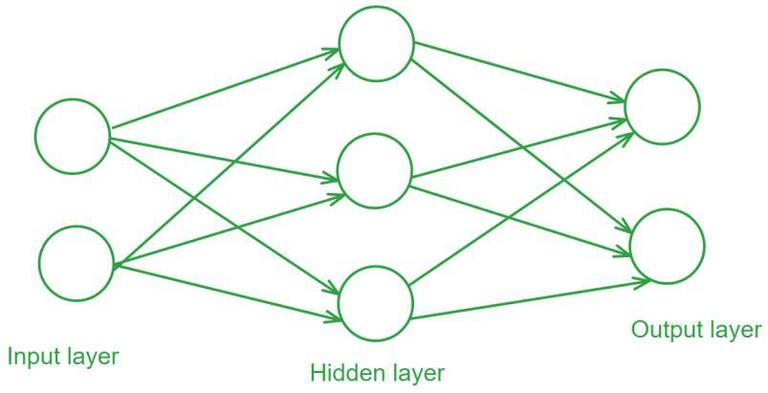

## Deep Learning Libraries

Creating neural networks often involves using libraries such as TensorFlow, PyTorch, or Keras. TensorFlow, developed by Google, offers a robust platform for constructing and deploying neural networks, with a particular emphasis on scalability and production deployment. PyTorch, favored by researchers, is renowned for its dynamic computation graph, which makes model experimentation and debugging more intuitive. Keras, often used as a high-level API for TensorFlow, simplifies the creation of neural networks with its user-friendly syntax. While TensorFlow and PyTorch provide more granular control, Keras appeals to those looking to quickly prototype models with minimal boilerplate code. In this notebook, we'll primarily be using TensorFlow



## Problem Clarification

Feedforward Neural Networks (FNNs) are particularly well-suited for problems in which there is a need to map input data to a specific output, especially when the relationship between inputs and output is complex and nonlinear.

Stock market phenomena is inherently complex and nonlinear, making it a long-time candidate for deep-learning solutions. In this context, let's start with a relatively straightforward but nonetheless difficult task--classifying stocks as 'volatile' or 'stable'. Historically, volatility (a measure of fluctuation in stock prices) is calculated using the following algorithm:

1. Gather the security’s past prices.
2. Calculate the average price (mean) of the security’s past prices.
3. Determine the difference between each price in the set and the average price.
4. Square the differences from the previous step.
5. Sum the squared differences.
6. Divide the squared differences by the total number of prices in the set (find variance).
7. Calculate the square root of the number obtained in the previous step.

However, if we were working for a brokerage firm like Charles Schwab or Robinhood, or if we were beginning traders, we may just want to generate a warning that says, "This stock is volatile. Trade carefully." Further, we may want to incorporate data into our volatility calculation outside of just price as a function of time.

FNNs can take in various features such as historical price data, technical indicators like moving averages, and other market factors, and use these inputs to classify a stock’s volatility as either "stable" or "volatile."

The advantage of using an FNN for this type of classification problem lies in its ability to generalize from the training data and make predictions for new, unseen data. When applied to stock price volatility, the network doesn't need to explicitly understand the underlying economics or the above formula; instead, it can learn the intricate patterns and behaviors in the market that precede periods of high or low volatility. Once trained, the network can classify future stock movements as volatile or stable based on the features it has learned to associate with each class.

## Set Up and Preprocessing

Let's start by importing the necessary libraries.

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Instead of uploading a CSV as we've done in previous assignments, we're going to use the Yahoo Finance API via [`yfinance`](https://github.com/ranaroussi/yfinance). So that we can do this with multiple stocks, let's write a function to prepare stock data.

In [ ]:
# prepare_stock_data: Download stock data using Yahoo Finance API
def prepare_stock_data(ticker):
    # Fetch stock data using yfinance
    stock_data = yf.download(ticker, start='2020-01-01', end='2024-01-01')

    # Step 2: Calculate daily percentage change in closing price
    stock_data['Pct_Change'] = stock_data['Close'].pct_change() * 100  # Percentage change in closing price

    # Step 3: Define a 'Volatility' column based on price change
    # If the price change exceeds a threshold, classify it as volatile (1), else stable (0)
    stock_data['Volatility'] = stock_data['Pct_Change'].apply(lambda x: 1 if abs(x) > 2 else 0)

    # Step 4: Create rolling features
    stock_data['Rolling_Mean'] = stock_data['Close'].rolling(window=5).mean()  # 5-day moving average
    stock_data['Rolling_Std'] = stock_data['Close'].rolling(window=5).std()    # 5-day moving standard deviation

    # Drop NaN values created by rolling operations
    stock_data = stock_data.dropna()

    # Step 5: Prepare features (X) and target (y)
    X = stock_data[['Rolling_Mean', 'Rolling_Std']]  # Features: rolling mean and standard deviation
    y = stock_data['Volatility']  # Target: volatility (0 or 1)

    # Return the feature matrix X, target vector y, and the processed stock data
    return X, y, stock_data

## Model Implementation

To improve modularity, we're also going to create a function to train and evaluate the model. This is so that each stock generates a specific FNN and so we can repeat the process for different stocks and compare accuracies.

Notice that we are including some preprocessing steps, such as standardizing the data, which is very important for neural networks. Without standardization, features with larger magnitudes dominate the learning process, leading to slower convergence or suboptimal performance. Standardized data helps the model learn evenly from all features, improves numerical stability, and can prevent issues like exploding or vanishing gradients. By scaling inputs to a uniform range, the network's ability to generalize and make accurate predictions increases, yielding better overall performance.

### Important Functions in Implementation

1. `Sequential()`: Instantiates the neural network model. Allows you to build a model by stacking layers in a defined order, where the output of one layer becomes the input of the next.

2. `add()`: Adds a layer to the neural network model. Each layer must be compatible with the shape of the preceding layer, and you define its parameters, such as the number of neurons, activation functions, or kernel sizes. This method is used iteratively to construct the architecture of the model, ensuring that each layer is stacked sequentially.

3. `compile()`: Configures the model for training by specifying the optimizer, loss function, and metrics. The optimizer determines how the model updates weights, the loss function measures the difference between predictions and actual values, and metrics provide additional evaluation criteria during training. This step finalizes the model's configuration before it can be trained.

4. `evaluate()`: Assesses the model's performance on test data by computing the loss and any specified metrics. This function uses data the model has not seen during training to evaluate its generalization ability, returning quantitative results that reflect how well the model performs on unseen data.

5. `predict()`: Generates predictions from the trained model. It takes input data and outputs the model's predictions based on its learned parameters. This method is used for inference, allowing you to apply the trained model to new data and obtain predicted values, such as class probabilities or regression outputs.

Then we process model predictions for binary classification and organize the results in a structured format. First, we converts the raw predictions, which are probabilities, into binary labels (0 or 1) using a threshold of 0.5. Next, we map these predictions back to the original dates corresponding to the test set, ensuring the results align with the original dataset. The indices of the test set are retrieved, and the dates for these indices are extracted from the original stock data. Finally, a DataFrame is created to present the results, including the dates, actual volatility values from the test set, and the predicted binary volatility values. This DataFrame provides a summary of the model's predictions compared to actual outcomes.

In [ ]:
# train_and_evaluation: implements the model and evaluations it
def train_and_evaluate_model(X, y, stock_data):
    # Split data into training and testing sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Standardize the features (important for neural networks)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Build the neural network model
    model = Sequential()
    model.add(Dense(20, input_dim=X_train.shape[1], activation='relu'))  # Input layer (2 features)
    model.add(Dense(10, activation='relu'))  # Hidden layer
    model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)

    # Compile the model (binary classification)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

    # Evaluate the model on the test data
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Model Accuracy: {accuracy * 100:.2f}%')

    # Make predictions
    predictions = model.predict(X_test)

    # Convert predictions to binary (0 or 1)
    predicted_labels = (predictions > 0.5).astype(int)

    # Map predictions back to the correct dates in the original data
    # Get the indices of the test set in the original stock data
    test_indices = y_test.index

    # Get the corresponding dates from the original stock data
    test_dates = stock_data.loc[test_indices].index

    # Create a result DataFrame with dates, actual, and predicted values
    result_df = pd.DataFrame({
        'Date': test_dates,
        'Actual Volatility': y_test,
        'Predicted Volatility': predicted_labels.flatten()
    })

    return result_df

[*********************100%***********************]  1 of 1 completed

Epoch 1/20



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3909 - loss: 0.7192 - val_accuracy: 0.7065 - val_loss: 0.6805
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7043 - loss: 0.6731 - val_accuracy: 0.7363 - val_loss: 0.6455
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7326 - loss: 0.6418 - val_accuracy: 0.7413 - val_loss: 0.6115
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7534 - loss: 0.6025 - val_accuracy: 0.7413 - val_loss: 0.5773
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7213 - loss: 0.5841 - val_accuracy: 0.7413 - val_loss: 0.5493
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7243 - loss: 0.5572 - val_accuracy: 0.7512 - val_loss: 0.5290
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7255 - loss: 0.5369 - val_accuracy: 0.7512 - val_loss: 0.5102
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7568 - loss: 0.5106 - val_accuracy: 0.7612 - val_loss: 0.4982
Ep

[*********************100%***********************]  1 of 1 completed

...

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3195 - loss: 0.8209 - val_accuracy: 0.4527 - val_loss: 0.7128
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5141 - loss: 0.7002 - val_accuracy: 0.6766 - val_loss: 0.6567
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7255 - loss: 0.6352 - val_accuracy: 0.7065 - val_loss: 0.6241
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7826 - loss: 0.5819 - val_accuracy: 0.7065 - val_loss: 0.6014
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7537 - loss: 0.5664 - val_accuracy: 0.7065 - val_loss: 0.5820
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7703 - loss: 0.5278 - val_accuracy: 0.7065 - val_loss: 0.5637
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7460 - loss: 0.5232 - val_accuracy: 0.7164 - val_loss: 0.5501
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7809 - loss: 0.4792 - val_accuracy: 0.7164 - val_loss: 0.5440
Ep

[*********************100%***********************]  1 of 1 completed

Epoch 1/20



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4762 - loss: 0.6988 - val_accuracy: 0.6909 - val_loss: 0.6759
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6504 - loss: 0.6747 - val_accuracy: 0.6727 - val_loss: 0.6630
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6721 - loss: 0.6571 - val_accuracy: 0.6636 - val_loss: 0.6555
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7021 - loss: 0.6413 - val_accuracy: 0.6636 - val_loss: 0.6505
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7020 - loss: 0.6298 - val_accuracy: 0.6636 - val_loss: 0.6477
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6997 - loss: 0.6225 - val_accuracy: 0.6636 - val_loss: 0.6458
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6919 - loss: 0.6189 - val_accuracy: 0.6636 - val_loss: 0.6451
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6849 - loss: 0.6239 - val_accuracy: 0.6636 - val_loss: 0.6441
Ep

Now, let's test our model out. We'll do so by calling our `prepare_stock_data` and `train_and_evaluate_model` functions with specific stocks. We'll start with two stocks that should be fairly stable, and then try out a notoriously volatile stock like Cyngyn Inc. At the time that I'm writing this, Cyn has an implied volatility of 188.7, which is in the 97% percentile for volatility.

In [ ]:
# Test case 1: AAPL stock
X_aapl, y_aapl, aapl_data = prepare_stock_data('AAPL')
aapl_results = train_and_evaluate_model(X_aapl, y_aapl, aapl_data)
print("AAPL Stock Results:")
print(aapl_results.head())

# Test case 2: MSFT stock
X_msft, y_msft, msft_data = prepare_stock_data('MSFT')
msft_results = train_and_evaluate_model(X_msft, y_msft, msft_data)
print("\nMSFT Stock Results:")
print(msft_results.head())

# Test case 3: CYN stock (notoriously volatile)
X_cyn, y_cyn, cyn_data = prepare_stock_data('CYN')
cyn_results = train_and_evaluate_model(X_cyn, y_cyn, cyn_data)
print("\nCYN Stock Results:")
print(cyn_results.head())

[*********************100%***********************]  1 of 1 completed

Epoch 1/20



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3278 - loss: 0.7274 - val_accuracy: 0.6617 - val_loss: 0.6954
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6994 - loss: 0.6749 - val_accuracy: 0.7264 - val_loss: 0.6420
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7425 - loss: 0.6226 - val_accuracy: 0.7363 - val_loss: 0.5972
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7367 - loss: 0.5768 - val_accuracy: 0.7313 - val_loss: 0.5608
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7286 - loss: 0.5543 - val_accuracy: 0.7363 - val_loss: 0.5377
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7368 - loss: 0.5335 - val_accuracy: 0.7413 - val_loss: 0.5179
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7422 - loss: 0.5101 - val_accuracy: 0.7463 - val_loss: 0.5068
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7323 - loss: 0.5251 - val_accuracy: 0.7463 - val_loss: 0.4968
Epo

[*********************100%***********************]  1 of 1 completed

...

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5221 - loss: 0.6816 - val_accuracy: 0.7065 - val_loss: 0.6599
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7649 - loss: 0.6251 - val_accuracy: 0.7065 - val_loss: 0.6306
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7695 - loss: 0.5766 - val_accuracy: 0.7065 - val_loss: 0.6075
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7640 - loss: 0.5394 - val_accuracy: 0.7065 - val_loss: 0.5881
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7727 - loss: 0.5002 - val_accuracy: 0.7065 - val_loss: 0.5723
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7752 - loss: 0.4863 - val_accuracy: 0.7114 - val_loss: 0.5630
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7768 - loss: 0.4608 - val_accuracy: 0.7164 - val_loss: 0.5584
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7641 - loss: 0.4725 - val_accuracy: 0.7264 - val_loss: 0.5500
Epo

[*********************100%***********************]  1 of 1 completed

Epoch 1/20



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6952 - loss: 0.6418 - val_accuracy: 0.6636 - val_loss: 0.6776
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6859 - loss: 0.6348 - val_accuracy: 0.6636 - val_loss: 0.6716
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6801 - loss: 0.6307 - val_accuracy: 0.6636 - val_loss: 0.6682
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6480 - loss: 0.6376 - val_accuracy: 0.6636 - val_loss: 0.6675
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6750 - loss: 0.6248 - val_accuracy: 0.6636 - val_loss: 0.6667
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6947 - loss: 0.5949 - val_accuracy: 0.6636 - val_loss: 0.6667
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6764 - loss: 0.6106 - val_accuracy: 0.6636 - val_loss: 0.6636
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7013 - loss: 0.5919 - val_accuracy: 0.6636 - val_loss: 0.6593
Ep

✅ Try it yourself: Find a stock whose volality you're curious about and create a fourth test case. Is your stock more or less volatile that the other stocks we've looked at?

In [ ]:
# Your Code Here

## 🤺 Challenge: Use an FNN to predict whether a stock price will go up or down the next day.

1. Data Collection: Use the `yfinance` Yahoo API to pull historical stock data for a single company over a period (e.g., the last 6 months).
2. Feature Engineering: Calculate simple features such as the daily percent change in price, the moving average (e.g., 5-day and 30-day), and the Relative Strength Index (RSI).
3. Task: Use the features to train an FNN to predict whether the stock price will go up or down the next day (binary classification). The target variable can be defined as 1 if the next day's price is higher and 0 if it is lower.

Focus on just one stock at a time and limit the number of features.

### More on Feature Engineering

Feature engineering is the process of transforming raw data into meaningful features that can be used to train machine learning models. It involves selecting, modifying, or creating new input variables (features) from the original data to improve the model's performance. In the context of this challenge, some of the features you'll need could include:

**Moving Average**: A moving average is a statistical calculation that helps smooth out stock price fluctuations by averaging the price over a set period of time. This makes it easier to identify trends. For this assignment, you can introduce two simple types of moving averages: the 5-day moving average and the 30-day moving average.

5-Day Moving Average:
This average looks at the last 5 days' closing prices and averages them together.
For each day, calculate the average of the closing prices for that day and the previous four days.
For example:

On day 6, the 5-day moving average is the average of the closing prices from day 2 to day 6.

You could implement this in Python by using the `rolling()` function:

`stock_data['5-day MA'] = stock_data['Close'].rolling(window=5).mean()`

30-Day Moving Average:
This is similar, but it uses a longer period of 30 days to smooth out the price even further.
For each day after day 30, the 30-day moving average will be the average of the last 30 closing prices.
These moving averages can be helpful because:

If the short-term moving average (like the 5-day) is above the long-term moving average (like the 30-day), it suggests an upward trend.
If the short-term moving average is below the long-term moving average, it may indicate a downward trend.

**Relative Strength Index (RSI)**: The Relative Strength Index (RSI) measures the speed and change of price movements. It helps identify whether a stock is overbought or oversold, which could suggest a reversal in price direction.

The RSI is calculated based on the average gains and losses over a set period, usually 14 days. It ranges from 0 to 100:

RSI above 70: Indicates that the stock may be overbought (price may drop).
RSI below 30: Indicates that the stock may be oversold (price may rise).
How to Calculate RSI:
Calculate the daily price change by subtracting the previous day's closing price from the current day's closing price.
Separate the gains from the losses. If the change is positive, it's a gain; if it's negative, it's a loss. (Negative changes are taken as zero for calculating gains).
Calculate the average gain and average loss over the last 14 days.
Calculate the Relative Strength (RS), which is the ratio of the average gain to the average loss.

**Disclaimer:** While neural networks and machine learning models can be powerful tools for analyzing stock data and predicting price movements, it is important to understand that these models are not infallible. Stock market prediction is inherently uncertain. If your FNN for this challenge is not as accurate as you would like, that's to be expected. Predicting stock price trends is still an open problem.


In [ ]:
# Your Code Here

## Conclusion

In this notebook, we’ve explored the fundamentals of neural networks and how they can be applied to tasks like stock market prediction. While stock prediction is one fascinating application, neural networks have a broad range of uses across various fields. Beyond finance, these models are transforming industries by enabling advancements in areas such as healthcare, natural language processing, computer vision, and autonomous systems.

In healthcare, neural networks are used for tasks like medical image analysis, disease diagnosis, and drug discovery. In natural language processing, they power applications such as language translation, sentiment analysis, and chatbots. Neural networks are also driving innovations in self-driving cars, enabling them to perceive their surroundings and make decisions based on real-time data.

As neural network models continue to evolve, their potential applications will expand even further, solving complex problems in ways that were previously unimaginable.

### 📑 Sources:

1. [Exploring Convolution Neural Networks](https://medium.com/@tam.tamanna18/exploring-convolutional-neural-networks-architecture-steps-use-cases-and-pros-and-cons-b0d3b7d46c71), Tamanna | Medium
2. [How I Taught Myself Deep Learning: Vanilla NNs](https://www.kaggle.com/code/andradaolteanu/how-i-taught-myself-deep-learning-vanilla-nns#3.1-Youtube-Videos-that-will-save-you-time:), Andrada | Kaggle
3. [Neural Network Models for Stock Selection Based on Fundamental Analysis](https://arxiv.org/pdf/1906.05327) | Huang, Capretz, Ho 2019
4. [Predicting High-Frequency Stock Market by Neural Networks](https://www.imperial.ac.uk/media/imperial-college/faculty-of-natural-sciences/department-of-mathematics/math-finance/Tu_Yuchen_01219050.pdf) | Tu, Imperial college London 2019
5. [Interpreting Loss Curves](https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves) | Google Machine Learning